Federated Quantum CNN

In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.python.framework.errors_impl import ResourceExhaustedError
from sklearn.model_selection import KFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
import pennylane as qml
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import json
from datetime import datetime
import gc, os, numpy as np
import time

In [4]:
# Set seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

In [5]:
# ============================================
# QUANTUM LAYER DEFINITION (Same as QCNN.py)
# ============================================
N_QUBITS = 4
N_LAYERS = 2

# Initialize quantum device
dev = qml.device("default.qubit", wires=N_QUBITS)

def quantum_circuit(inputs, weights):
    """Quantum circuit with data encoding and trainable layers"""
    # Encode classical data into quantum states
    for i in range(N_QUBITS):
        qml.RY(inputs[i], wires=i)
    
    # Variational quantum layers
    for layer in range(N_LAYERS):
        # Entangling layer
        for i in range(N_QUBITS):
            qml.RY(weights[layer, i, 0], wires=i)
            qml.RZ(weights[layer, i, 1], wires=i)
        
        # CNOT entanglement
        for i in range(N_QUBITS - 1):
            qml.CNOT(wires=[i, i + 1])
        qml.CNOT(wires=[N_QUBITS - 1, 0])
    
    # Measure expectations
    return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]

# Create QNode
qnode = qml.QNode(quantum_circuit, dev, interface='autograd')

In [6]:
class QuantumInspiredLayer(layers.Layer):
    """
    Quantum-inspired layer that emulates quantum behavior with classical operations.
    Same implementation as QCNN.py for consistency.
    """
    def __init__(self, n_qubits, n_layers, **kwargs):
        super(QuantumInspiredLayer, self).__init__(**kwargs)
        self.n_qubits = n_qubits
        self.n_layers = n_layers
        
    def build(self, input_shape):
        # Quantum-inspired rotation parameters
        self.rotation_weights = self.add_weight(
            name="rotation_weights",
            shape=(self.n_layers, self.n_qubits, 2),
            initializer=keras.initializers.RandomUniform(0, 2*np.pi),
            trainable=True
        )
        
        # Entanglement interaction weights
        self.interaction_weights = self.add_weight(
            name="interaction_weights",
            shape=(self.n_layers, self.n_qubits, self.n_qubits),
            initializer=keras.initializers.GlorotUniform(),
            trainable=True
        )
        
        super().build(input_shape)
    
    def call(self, inputs):
        """Quantum-inspired transformation using rotation and entanglement-like operations"""
        x = inputs
        
        for layer in range(self.n_layers):
            # Rotation-like transformations (inspired by RY, RZ gates)
            ry_transform = tf.cos(self.rotation_weights[layer, :, 0]) * x + \
                          tf.sin(self.rotation_weights[layer, :, 0]) * tf.roll(x, shift=1, axis=-1)
            
            rz_transform = tf.cos(self.rotation_weights[layer, :, 1]) * ry_transform - \
                          tf.sin(self.rotation_weights[layer, :, 1]) * tf.roll(ry_transform, shift=-1, axis=-1)
            
            # Entanglement-like interaction (inspired by CNOT gates)
            interaction = tf.matmul(
                tf.expand_dims(rz_transform, axis=-1),
                tf.expand_dims(rz_transform, axis=-2)
            )
            
            # Apply learned interaction weights
            interaction_effect = tf.reduce_sum(
                interaction * self.interaction_weights[layer], 
                axis=-1
            )
            
            # Non-linear activation mimicking quantum measurement probabilities
            x = tf.tanh(rz_transform + 0.1 * interaction_effect)
        
        return x
    
    def get_config(self):
        config = super().get_config()
        config.update({
            "n_qubits": self.n_qubits,
            "n_layers": self.n_layers,
        })
        return config


In [7]:
# ============================================
# CLIENT SEQUENCE (Same as FLCNN.py)
# ============================================
class ClientSequence(keras.utils.Sequence):
    """Loads images from disk on-the-fly for a client. Avoids loading whole dataset into memory."""
    def __init__(self, filepaths, labels, img_size=(64, 64), batch_size=16, num_classes=4, shuffle=True):
        self.filepaths = np.array(filepaths)
        self.labels = np.array(labels)
        self.img_size = img_size
        self.batch_size = batch_size
        self.num_classes = num_classes
        self.shuffle = shuffle
        self.indexes = np.arange(len(self.filepaths))
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.filepaths) / float(self.batch_size)))

    def __getitem__(self, index):
        batch_idx = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        batch_files = self.filepaths[batch_idx]
        batch_labels = self.labels[batch_idx]
        X = np.zeros((len(batch_files), *self.img_size, 3), dtype=np.float32)
        y = np.zeros((len(batch_files), self.num_classes), dtype=np.float32)
        for i, fp in enumerate(batch_files):
            img = cv2.imread(fp)
            if img is None:
                img = np.zeros((self.img_size[0], self.img_size[1], 3), dtype=np.uint8)
            else:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, self.img_size)
            img = img.astype(np.float32) / 255.0
            y[i, int(batch_labels[i])] = 1.0
            X[i] = img
        return X, y

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indexes)

In [8]:
# ============================================
# FEDERATED QUANTUM CNN CLASS
# ============================================
class FederatedQuantumCNN:
    """
    Federated Learning with Quantum-Inspired CNN
    Combines FL architecture from FLCNN.py with Quantum layer from QCNN.py
    """
    def __init__(self, num_clients=5, img_size=(64, 64), num_classes=4, class_names=None):
        self.num_clients = num_clients
        self.img_size = img_size
        self.num_classes = num_classes
        self.class_names = class_names or ['glioma', 'meningioma', 'notumor', 'pituitary']
        self.global_model = None
        self.history = {'val_accuracy': [], 'val_loss': []}
        self.n_qubits = N_QUBITS
        self.n_layers = N_LAYERS

    def create_quantum_cnn_model(self):
        """
        Create Hybrid Quantum-Classical CNN architecture
        Architecture matches QCNN.py but adapted for federated learning
        """
        inputs = layers.Input(shape=(*self.img_size, 3))
        
        # Classical convolutional layers (same as QCNN.py)
        x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling2D((2, 2))(x)
        x = layers.Dropout(0.25)(x)
        
        x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling2D((2, 2))(x)
        x = layers.Dropout(0.25)(x)
        
        x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling2D((2, 2))(x)
        x = layers.Dropout(0.25)(x)
        
        x = layers.Flatten()(x)
        x = layers.Dense(64, activation='relu')(x)
        x = layers.Dropout(0.5)(x)
        
        # Dimensionality reduction for quantum layer
        x = layers.Dense(self.n_qubits, activation='tanh', name='quantum_input')(x)
        
        # Quantum-inspired layer
        x = QuantumInspiredLayer(self.n_qubits, self.n_layers, name='quantum_layer')(x)
        
        # Classical output layer
        outputs = layers.Dense(self.num_classes, activation='softmax')(x)
        
        model = models.Model(inputs=inputs, outputs=outputs)
        
        model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=0.001),
            loss='categorical_crossentropy', 
            metrics=['accuracy']
        )
        return model

    def load_data_generators(self, train_dir, test_dir, batch_size=16):
        """Return ImageDataGenerators (same as FLCNN.py)"""
        train_datagen = ImageDataGenerator(
            rescale=1./255,
            rotation_range=20,
            width_shift_range=0.2,
            height_shift_range=0.2,
            horizontal_flip=True,
            zoom_range=0.2,
            fill_mode='nearest',
            validation_split=0.2
        )
        test_datagen = ImageDataGenerator(rescale=1./255)

        train_generator = train_datagen.flow_from_directory(
            train_dir,
            target_size=self.img_size,
            batch_size=batch_size,
            class_mode='categorical',
            subset='training',
            shuffle=True
        )

        val_generator = train_datagen.flow_from_directory(
            train_dir,
            target_size=self.img_size,
            batch_size=batch_size,
            class_mode='categorical',
            subset='validation',
            shuffle=False
        )

        test_generator = test_datagen.flow_from_directory(
            test_dir,
            target_size=self.img_size,
            batch_size=batch_size,
            class_mode='categorical',
            shuffle=False
        )

        idx_to_class = {v: k for k, v in train_generator.class_indices.items()}
        self.class_names = [idx_to_class[i] for i in range(len(idx_to_class))]

        return train_generator, val_generator, test_generator

    def split_filepaths_for_clients(self, train_generator):
        """Create per-client filepaths+labels lists (same as FLCNN.py)"""
        filepaths = np.array(train_generator.filepaths)
        labels = np.array(train_generator.classes, dtype=int)

        indices = np.arange(len(filepaths))
        np.random.shuffle(indices)
        splits = np.array_split(indices, self.num_clients) 

        client_filelists = []
        for s in splits:
            client_filelists.append((filepaths[s].tolist(), labels[s].tolist()))
        return client_filelists

    def train_federated(self, train_dir, val_generator, num_rounds=5, local_epochs=6, batch_size=16, start_round=1):
        """
        Federated training with Quantum CNN
        Same federated logic as FLCNN.py but with Quantum model
        """
        print("\n========== FEDERATED QUANTUM CNN TRAINING STARTED ==========")
        print(f"Clients: {self.num_clients}, Rounds: {num_rounds}, Local epochs: {local_epochs}")
        print(f"Batch size: {batch_size}, Qubits: {self.n_qubits}, Quantum layers: {self.n_layers}")
        print(f"Starting Round: {start_round}")

        # Ensure global model exists
        if self.global_model is None:
            if start_round > 1:
                raise ValueError("Must load a checkpoint into self.global_model before resuming.")
            self.global_model = self.create_quantum_cnn_model()

        # Build base generator for splitting
        base_datagen = ImageDataGenerator(rescale=1./255)
        base_gen = base_datagen.flow_from_directory(
            train_dir,
            target_size=self.img_size,
            batch_size=batch_size,
            class_mode='categorical',
            shuffle=False
        )

        client_filelists = self.split_filepaths_for_clients(base_gen)

        if not hasattr(self, 'history') or not isinstance(self.history, dict):
            self.history = {'val_accuracy': [], 'val_loss': []}

        # Federated rounds
        for round_num in range(start_round - 1, num_rounds):
            print(f"\n{'='*70}")
            print(f"FEDERATED ROUND {round_num + 1}/{num_rounds}")
            print('='*70)
            client_weights = []

            for client_id, (filepaths, labels) in enumerate(client_filelists):
                print(f"\n  -> Training Client {client_id + 1}/{self.num_clients}")
                print(f"     Samples: {len(filepaths)}")

                # Create client model and load global weights
                client_model = self.create_quantum_cnn_model()
                client_model.set_weights(self.global_model.get_weights())

                # OOM-resilient training
                success = False
                attempt = 0
                cur_batch = batch_size
                cur_img_size = self.img_size
                tmp_path = os.path.join("tmp_models", f"fqcnn_global_r{round_num+1}_c{client_id+1}.keras")

                while not success and attempt < 4:
                    try:
                        print(f"     Attempt {attempt+1}: batch={cur_batch}, img_size={cur_img_size}")
                        
                        seq = ClientSequence(filepaths, labels, img_size=cur_img_size, 
                                           batch_size=cur_batch, num_classes=self.num_classes, 
                                           shuffle=True)

                        if cur_img_size != self.img_size:
                            client_model = self.create_quantum_cnn_model()
                            client_model.set_weights(self.global_model.get_weights())

                        callbacks = [
                            EarlyStopping(patience=3, restore_best_weights=True, verbose=0, monitor='loss'),
                            ReduceLROnPlateau(factor=0.5, patience=2, verbose=0, monitor='loss')
                        ]
                        
                        # Train on client
                        client_start = time.time()
                        client_model.fit(seq, epochs=local_epochs, verbose=1, callbacks=callbacks)
                        client_time = time.time() - client_start
                        print(f"     ✓ Client training completed in {client_time:.2f}s")

                        success = True

                    except ResourceExhaustedError as oom:
                        print("     !! OOM during client training")
                        try:
                            os.makedirs("tmp_models", exist_ok=True)
                            self.global_model.save(tmp_path)
                            print(f"     Saved temporary model to {tmp_path}")
                        except Exception as e:
                            print(f"     Warning: could not save temp model: {e}")

                        tf.keras.backend.clear_session()
                        gc.collect()

                        self.global_model = self.create_quantum_cnn_model()
                        if os.path.exists(tmp_path):
                            try:
                                self.global_model = tf.keras.models.load_model(tmp_path)
                                print("     Reloaded temporary model")
                            except Exception:
                                print("     Could not reload temp model")

                        attempt += 1
                        cur_batch = max(1, cur_batch // 2)
                        if attempt >= 2:
                            cur_img_size = (max(64, cur_img_size[0] // 2), max(64, cur_img_size[1] // 2))

                        client_model = self.create_quantum_cnn_model()
                        client_model.set_weights(self.global_model.get_weights())

                    except Exception as e:
                        print(f"     Unexpected error: {type(e).__name__}: {e}")
                        try:
                            os.makedirs("tmp_models", exist_ok=True)
                            self.global_model.save(os.path.join("tmp_models", f"fqcnn_error_r{round_num+1}_c{client_id+1}.keras"))
                        except Exception:
                            pass
                        raise

                if not success:
                    raise RuntimeError(f"Client {client_id + 1} training failed after retries.")

                client_weights.append(client_model.get_weights())

                try:
                    del client_model
                except Exception:
                    pass
                gc.collect()

            # Federated averaging
            print("\n  Aggregating client weights (FedAvg)...")
            averaged_weights = []
            for layer_weights in zip(*client_weights):
                stacked = np.stack(layer_weights, axis=0)
                averaged = np.mean(stacked, axis=0)
                averaged_weights.append(averaged)

            self.global_model.set_weights(averaged_weights)

            # Evaluate global model
            print("  Evaluating global quantum model...")
            val_loss, val_accuracy = self.global_model.evaluate(val_generator, verbose=1)
            print(f"\n  [Round {round_num + 1}] Val Accuracy: {val_accuracy:.4f} | Val Loss: {val_loss:.4f}")

            if len(self.history['val_loss']) < (round_num + 1):
                self.history['val_loss'].append(float(val_loss))
                self.history['val_accuracy'].append(float(val_accuracy))

            # Save checkpoint
            try:
                os.makedirs("models", exist_ok=True)
                ckpt_path = os.path.join("models", f"federated_quantum_model_round_{round_num + 1}.keras")
                self.global_model.save(ckpt_path)
                print(f"  ✓ Saved checkpoint: {ckpt_path}")
            except Exception as e:
                print(f"  Warning: failed to save checkpoint: {e}")

            gc.collect()

        print("\n========== FEDERATED QUANTUM CNN TRAINING COMPLETED ==========")
        return self.global_model

    def kfold_cross_validation(self, train_dir, k_folds=5, batch_size=16):
        """K-fold cross-validation with Quantum CNN (same structure as FLCNN.py)"""
        print("\n" + "="*70)
        print("K-FOLD CROSS-VALIDATION (QUANTUM CNN)")
        print("="*70)

        datagen = ImageDataGenerator(rescale=1./255)
        full_generator = datagen.flow_from_directory(
            train_dir,
            target_size=self.img_size,
            batch_size=batch_size,
            class_mode='categorical',
            shuffle=False
        )

        filepaths = np.array(full_generator.filepaths)
        labels = np.array(full_generator.classes, dtype=int)

        x_dummy = np.arange(len(filepaths))

        kfold = KFold(n_splits=k_folds, shuffle=True, random_state=42)
        fold_scores = []

        for fold, (train_idx, val_idx) in enumerate(kfold.split(x_dummy)):
            print(f"\n-- Fold {fold + 1}/{k_folds} --")
            train_files = filepaths[train_idx]
            train_labels = labels[train_idx]
            val_files = filepaths[val_idx]
            val_labels = labels[val_idx]

            train_seq = ClientSequence(train_files, train_labels, img_size=self.img_size, 
                                      batch_size=batch_size, num_classes=self.num_classes, shuffle=True)
            val_seq = ClientSequence(val_files, val_labels, img_size=self.img_size, 
                                    batch_size=batch_size, num_classes=self.num_classes, shuffle=False)

            model = self.create_quantum_cnn_model()
            callbacks = [
                EarlyStopping(patience=5, restore_best_weights=True, verbose=0),
                ReduceLROnPlateau(factor=0.5, patience=3, verbose=0)
            ]

            model.fit(train_seq, validation_data=val_seq, epochs=30, verbose=1, callbacks=callbacks) 
            _, accuracy = model.evaluate(val_seq, verbose=0)
            fold_scores.append(float(accuracy))
            print(f"Fold {fold + 1} Accuracy: {accuracy:.4f}")

            try:
                del model
            except Exception:
                pass
            tf.keras.backend.clear_session()
            gc.collect()

        print(f"\nQuantum CNN K-Fold Mean Accuracy: {np.mean(fold_scores):.4f} (+/- {np.std(fold_scores):.4f})")
        return fold_scores

    def evaluate_model(self, test_generator):
        """Evaluate model on test set (same as FLCNN.py)"""
        print("\n" + "="*70)
        print("FEDERATED QUANTUM CNN - TEST SET EVALUATION")
        print("="*70)

        y_pred_probs = self.global_model.predict(test_generator, verbose=1)
        y_pred = np.argmax(y_pred_probs, axis=1)
        y_true = test_generator.classes

        accuracy = accuracy_score(y_true, y_pred)
        print(f"Test Accuracy: {accuracy:.4f}")

        report = classification_report(y_true, y_pred, target_names=self.class_names, digits=4)
        print(report)

        cm = confusion_matrix(y_true, y_pred)
        
        # Per-class analysis
        precision, recall, f1, support = precision_recall_fscore_support(
            y_true, y_pred, average=None, labels=range(len(self.class_names))
        )
        
        print("\n" + "-"*70)
        print("PER-CLASS PERFORMANCE")
        print("-"*70)
        for i, class_name in enumerate(self.class_names):
            print(f"\n{class_name.upper()}:")
            print(f"  Precision: {precision[i]:.4f}")
            print(f"  Recall: {recall[i]:.4f}")
            print(f"  F1-Score: {f1[i]:.4f}")
            print(f"  Support: {support[i]}")
        
        return y_true, y_pred, y_pred_probs, cm, accuracy

    def plot_training_history(self):
        """Plot training history (same as FLCNN.py)"""
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        axes[0].plot(range(1, len(self.history['val_accuracy'])+1), 
                    self.history['val_accuracy'], marker='o', linewidth=2, color='green')
        axes[0].set_title('Federated Quantum CNN - Validation Accuracy', fontweight='bold')
        axes[0].set_xlabel('Federated Round')
        axes[0].set_ylabel('Accuracy')
        axes[0].grid(True, alpha=0.3)
        axes[0].set_ylim([0, 1])

        axes[1].plot(range(1, len(self.history['val_loss'])+1), 
                    self.history['val_loss'], marker='o', linewidth=2, color='red')
        axes[1].set_title('Federated Quantum CNN - Validation Loss', fontweight='bold')
        axes[1].set_xlabel('Federated Round')
        axes[1].set_ylabel('Loss')
        axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig('fqcnn_training_history.png', dpi=300, bbox_inches='tight')
        plt.show()
        print("Saved: fqcnn_training_history.png")

    def plot_confusion_matrix(self, cm):
        """Plot confusion matrix (same as FLCNN.py)"""
        plt.figure(figsize=(9, 7))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                   xticklabels=self.class_names, yticklabels=self.class_names)
        plt.title('Federated Quantum CNN - Confusion Matrix', fontweight='bold')
        plt.ylabel('True Label')
        plt.xlabel('Predicted Label')
        plt.tight_layout()
        plt.savefig('fqcnn_confusion_matrix.png', dpi=300, bbox_inches='tight')
        plt.show()
        print("Saved: fqcnn_confusion_matrix.png")

    def plot_performance_metrics(self, y_true, y_pred):
        """Plot performance metrics (same as FLCNN.py)"""
        precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average=None)
        x = np.arange(len(self.class_names))
        width = 0.25
        
        fig, ax = plt.subplots(figsize=(10, 5))
        ax.bar(x - width, precision, width, label='Precision', color='#FF6B6B')
        ax.bar(x, recall, width, label='Recall', color='#4ECDC4')
        ax.bar(x + width, f1, width, label='F1-Score', color='#45B7D1')
        ax.set_xticks(x)
        ax.set_xticklabels(self.class_names, rotation=45)
        ax.set_ylabel('Score')
        ax.set_ylim([0, 1.05])
        ax.set_title('Federated Quantum CNN - Performance Metrics', fontweight='bold')
        ax.legend()
        ax.grid(True, alpha=0.3, axis='y')
        
        plt.tight_layout()
        plt.savefig('fqcnn_performance_metrics.png', dpi=300, bbox_inches='tight')
        plt.show()
        print("Saved: fqcnn_performance_metrics.png")

    def visualize_quantum_layer(self, test_generator, num_samples=4):
        """Visualize quantum layer activations"""
        print("\n" + "="*70)
        print("QUANTUM LAYER VISUALIZATION")
        print("="*70)
        
        quantum_model = keras.Model(
            inputs=self.global_model.input,
            outputs=self.global_model.get_layer('quantum_layer').output
        )
        
        # Get sample images
        test_images = []
        test_labels = []
        for _ in range(num_samples):
            batch_x, batch_y = next(iter(test_generator))
            test_images.append(batch_x[0])
            test_labels.append(np.argmax(batch_y[0]))
        
        fig, axes = plt.subplots(num_samples, 2, figsize=(12, 3*num_samples))
        if num_samples == 1:
            axes = axes.reshape(1, 2)
        
        for idx in range(num_samples):
            img = np.expand_dims(test_images[idx], axis=0)
            
            # Get quantum layer activation
            quantum_output = quantum_model.predict(img, verbose=0)[0]
            
            # Original image
            axes[idx, 0].imshow(test_images[idx])
            axes[idx, 0].set_title(f'Input: {self.class_names[test_labels[idx]]}', fontweight='bold')
            axes[idx, 0].axis('off')
            
            # Quantum activation
            axes[idx, 1].bar(range(self.n_qubits), quantum_output, color='green', alpha=0.7)
            axes[idx, 1].set_title('Quantum Layer Activations', fontweight='bold')
            axes[idx, 1].set_xlabel('Qubit Index')
            axes[idx, 1].set_ylabel('Activation Value')
            axes[idx, 1].set_ylim([-1, 1])
            axes[idx, 1].grid(True, alpha=0.3)
            axes[idx, 1].axhline(y=0, color='black', linestyle='--', linewidth=1)
        
        plt.tight_layout()
        plt.savefig('fqcnn_quantum_activations.png', dpi=300, bbox_inches='tight')
        plt.show()
        print("Saved: fqcnn_quantum_activations.png")

    def save_results(self, fold_scores, test_accuracy):
        """Save results to JSON (same as FLCNN.py)"""
        results = {
            'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
            'model_type': 'Federated Quantum CNN',
            'model_config': {
                'num_clients': self.num_clients, 
                'image_size': self.img_size, 
                'num_classes': self.num_classes,
                'n_qubits': self.n_qubits,
                'n_quantum_layers': self.n_layers
            },
            'kfold_results': {
                'fold_scores': [float(s) for s in fold_scores], 
                'mean_accuracy': float(np.mean(fold_scores)),
                'std_accuracy': float(np.std(fold_scores))
            },
            'test_accuracy': float(test_accuracy),
            'training_history': {
                'val_accuracy': [float(x) for x in self.history['val_accuracy']],
                'val_loss': [float(x) for x in self.history['val_loss']]
            }
        }
        with open('federated_quantum_cnn_results.json', 'w') as f:
            json.dump(results, f, indent=4)
        print("Saved: federated_quantum_cnn_results.json")


In [7]:

# ============================================
# MAIN FUNCTION
# ============================================
def main():
    """Main training and evaluation pipeline"""
    
    TRAIN_DIR = 'Brain_Tumor_data/Training'
    TEST_DIR = 'Brain_Tumor_data/Testing'
    
    # Configuration matching other models
    NUM_CLIENTS = 5
    NUM_FEDERATED_ROUNDS = 5
    LOCAL_EPOCHS = 6
    K_FOLDS = 5
    BATCH_SIZE = 16
    IMG_SIZE = (64, 64)

    print("\n" + "="*70)
    print("FEDERATED QUANTUM CNN - CONFIGURATION")
    print("="*70)
    print(f"  Clients: {NUM_CLIENTS}")
    print(f"  Federated Rounds: {NUM_FEDERATED_ROUNDS}")
    print(f"  Local Epochs per Round: {LOCAL_EPOCHS}")
    print(f"  K-Folds: {K_FOLDS}")
    print(f"  Batch Size: {BATCH_SIZE}")
    print(f"  Image Size: {IMG_SIZE}")
    print(f"  Quantum Qubits: {N_QUBITS}")
    print(f"  Quantum Layers: {N_LAYERS}")
    print("="*70)

    # Initialize Federated Quantum CNN
    fqcnn = FederatedQuantumCNN(num_clients=NUM_CLIENTS, img_size=IMG_SIZE)
    
    # Load data generators
    train_gen, val_gen, test_gen = fqcnn.load_data_generators(TRAIN_DIR, TEST_DIR, batch_size=BATCH_SIZE)
    print(f"\nDataset Info:")
    print(f"  Training samples: {train_gen.samples}")
    print(f"  Validation samples: {val_gen.samples}")
    print(f"  Test samples: {test_gen.samples}")
    print(f"  Classes: {fqcnn.class_names}")

    # K-fold Cross-Validation (Centralized Baseline for Quantum CNN)
    print("\n" + "="*70)
    print("PHASE 1: K-FOLD CROSS-VALIDATION (CENTRALIZED QUANTUM CNN BASELINE)")
    print("="*70)
    fold_start_time = time.time()
    fold_scores = fqcnn.kfold_cross_validation(TRAIN_DIR, k_folds=K_FOLDS, batch_size=BATCH_SIZE)
    fold_total_time = time.time() - fold_start_time
    print(f"\nK-Fold Training Time: {fold_total_time:.2f} seconds ({fold_total_time/60:.2f} minutes)")

    # Federated Training (Main Contribution)
    print("\n" + "="*70)
    print("PHASE 2: FEDERATED QUANTUM CNN TRAINING")
    print("="*70)
    fed_start_time = time.time()
    global_model = fqcnn.train_federated(
        TRAIN_DIR, 
        val_gen, 
        num_rounds=NUM_FEDERATED_ROUNDS,
        local_epochs=LOCAL_EPOCHS, 
        batch_size=BATCH_SIZE
    )
    fed_total_time = time.time() - fed_start_time
    print(f"\nFederated Training Time: {fed_total_time:.2f} seconds ({fed_total_time/60:.2f} minutes)")

    # Plot training history
    fqcnn.plot_training_history()

    # Evaluate on Test Set
    print("\n" + "="*70)
    print("PHASE 3: TEST SET EVALUATION")
    print("="*70)
    y_true, y_pred, y_pred_probs, cm, test_acc = fqcnn.evaluate_model(test_gen)
    
    # Visualizations
    fqcnn.plot_confusion_matrix(cm)
    fqcnn.plot_performance_metrics(y_true, y_pred)
    fqcnn.visualize_quantum_layer(test_gen, num_samples=4)

    # Save results
    fqcnn.save_results(fold_scores, test_acc)
    
    # Save model
    try:
        global_model.save('federated_quantum_brain_tumor_model.h5')
        print("\nSaved model: federated_quantum_brain_tumor_model.h5")
    except Exception as e:
        print(f"\nWarning: Could not save .h5 format: {e}")
    
    global_model.save('federated_quantum_brain_tumor_model.keras')
    print("Saved model: federated_quantum_brain_tumor_model.keras")

    # Print final summary
    print("\n" + "="*70)
    print("TRAINING SUMMARY")
    print("="*70)
    print(f"Centralized Quantum CNN (K-Fold):")
    print(f"  Mean Accuracy: {np.mean(fold_scores):.4f} ± {np.std(fold_scores):.4f}")
    print(f"  Training Time: {fold_total_time/60:.2f} minutes")
    print(f"\nFederated Quantum CNN:")
    print(f"  Final Round Accuracy: {fqcnn.history['val_accuracy'][-1]:.4f}")
    print(f"  Final Round Loss: {fqcnn.history['val_loss'][-1]:.4f}")
    print(f"  Training Time: {fed_total_time/60:.2f} minutes")
    print(f"  Test Accuracy: {test_acc:.4f}")
    print("\nGenerated Files:")
    print("  1. federated_quantum_brain_tumor_model.keras - Trained model")
    print("  2. fqcnn_training_history.png - Training curves")
    print("  3. fqcnn_confusion_matrix.png - Confusion matrix")
    print("  4. fqcnn_performance_metrics.png - Per-class metrics")
    print("  5. fqcnn_quantum_activations.png - Quantum layer visualization")
    print("  6. federated_quantum_cnn_results.json - Complete results")
    print("="*70)
    print("✓ Federated Quantum CNN Training Complete!")
    print("="*70)


In [8]:
# ============================================
# RESUME TRAINING (Optional)
# ============================================
def resume_training():
    """
    Resume federated training from a checkpoint
    Usage: Uncomment and run this instead of main() if resuming
    """
    import os
    from tensorflow.keras.models import load_model
    
    # Force CPU if needed
    os.environ['CUDA_VISIBLE_DEVICES'] = '-1'
    tf.config.optimizer.set_jit(False)
    
    # Configuration
    TRAIN_DIR = 'Brain_Tumor_data/Training' 
    TEST_DIR = 'Brain_Tumor_data/Testing'   
    NUM_CLIENTS = 5
    NUM_FEDERATED_ROUNDS = 5
    LOCAL_EPOCHS = 6
    BATCH_SIZE = 16
    IMG_SIZE = (64, 64)
    
    # Resume setup
    START_ROUND = 4  # Resume from round 4
    CHECKPOINT_PATH = 'models/federated_quantum_model_round_3.keras'
    
    if not os.path.exists(CHECKPOINT_PATH):
        raise FileNotFoundError(f"Checkpoint not found: {CHECKPOINT_PATH}")
    
    print(f"✓ Resuming from checkpoint: {CHECKPOINT_PATH}")
    print(f"  Starting at Round {START_ROUND}")
    
    # Initialize
    fqcnn = FederatedQuantumCNN(num_clients=NUM_CLIENTS, img_size=IMG_SIZE)
    train_gen, val_gen, test_gen = fqcnn.load_data_generators(TRAIN_DIR, TEST_DIR, batch_size=BATCH_SIZE)
    
    # Load checkpoint
    print(f"\nLoading checkpoint...")
    fqcnn.global_model = load_model(CHECKPOINT_PATH, custom_objects={'QuantumInspiredLayer': QuantumInspiredLayer})
    print("✓ Checkpoint loaded successfully")
    
    # Resume training
    print(f"\n🚀 Resuming Federated Quantum CNN training from Round {START_ROUND}...")
    global_model = fqcnn.train_federated(
        TRAIN_DIR, 
        val_gen, 
        num_rounds=NUM_FEDERATED_ROUNDS,
        local_epochs=LOCAL_EPOCHS, 
        batch_size=BATCH_SIZE,
        start_round=START_ROUND
    )
    
    # Evaluate
    fold_scores = [0.8, 0.82, 0.79, 0.81, 0.83]  # Placeholder or load from file
    fqcnn.plot_training_history()
    y_true, y_pred, y_pred_probs, cm, test_acc = fqcnn.evaluate_model(test_gen)
    fqcnn.plot_confusion_matrix(cm)
    fqcnn.plot_performance_metrics(y_true, y_pred)
    fqcnn.visualize_quantum_layer(test_gen)
    fqcnn.save_results(fold_scores, test_acc)
    
    global_model.save('federated_quantum_brain_tumor_model_resumed.keras')
    print("\n✓ Saved resumed model: federated_quantum_brain_tumor_model_resumed.keras")


FEDERATED QUANTUM CNN - CONFIGURATION
  Clients: 5
  Federated Rounds: 5
  Local Epochs per Round: 6
  K-Folds: 5
  Batch Size: 16
  Image Size: (64, 64)
  Quantum Qubits: 4
  Quantum Layers: 2
Found 4571 images belonging to 4 classes.
Found 1141 images belonging to 4 classes.
Found 1311 images belonging to 4 classes.

Dataset Info:
  Training samples: 4571
  Validation samples: 1141
  Test samples: 1311
  Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']

PHASE 1: K-FOLD CROSS-VALIDATION (CENTRALIZED QUANTUM CNN BASELINE)

K-FOLD CROSS-VALIDATION (QUANTUM CNN)
Found 5712 images belonging to 4 classes.

-- Fold 1/5 --


I0000 00:00:1761774324.411033   21753 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1767 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2050, pci bus id: 0000:01:00.0, compute capability: 8.6
/mnt/c/Users/hassa/aiml/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30


2025-10-29 21:45:32.164774: I external/local_xla/xla/service/service.cc:163] XLA service 0x7fd59c015000 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-10-29 21:45:32.164812: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 2050, Compute Capability 8.6
2025-10-29 21:45:32.572160: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-10-29 21:45:33.512962: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91300


  2/286 ━━━━━━━━━━━━━━━━━━━━ 16s 58ms/step - accuracy: 0.2656 - loss: 1.4373   

I0000 00:00:1761774346.707312   22607 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


286/286 ━━━━━━━━━━━━━━━━━━━━ 66s 170ms/step - accuracy: 0.4323 - loss: 1.1680 - val_accuracy: 0.2948 - val_loss: 1.6171 - learning_rate: 0.0010
Epoch 2/30
286/286 ━━━━━━━━━━━━━━━━━━━━ 34s 119ms/step - accuracy: 0.4561 - loss: 1.1165 - val_accuracy: 0.5136 - val_loss: 1.1965 - learning_rate: 0.0010
Epoch 3/30
286/286 ━━━━━━━━━━━━━━━━━━━━ 35s 123ms/step - accuracy: 0.4463 - loss: 1.1144 - val_accuracy: 0.4619 - val_loss: 1.0880 - learning_rate: 0.0010
Epoch 4/30
286/286 ━━━━━━━━━━━━━━━━━━━━ 34s 118ms/step - accuracy: 0.4701 - loss: 1.0625 - val_accuracy: 0.4864 - val_loss: 0.9903 - learning_rate: 0.0010
Epoch 5/30
286/286 ━━━━━━━━━━━━━━━━━━━━ 32s 111ms/step - accuracy: 0.4806 - loss: 1.0390 - val_accuracy: 0.5074 - val_loss: 0.9636 - learning_rate: 0.0010
Epoch 6/30
286/286 ━━━━━━━━━━━━━━━━━━━━ 30s 105ms/step - accuracy: 0.4760 - loss: 1.0388 - val_accuracy: 0.5389 - val_loss: 0.9794 - learning_rate: 0.0010
Epoch 7/30
286/286 ━━━━━━━━━━━━━━━━━━━━ 30s 105ms/step - accuracy: 0.4920 - loss:

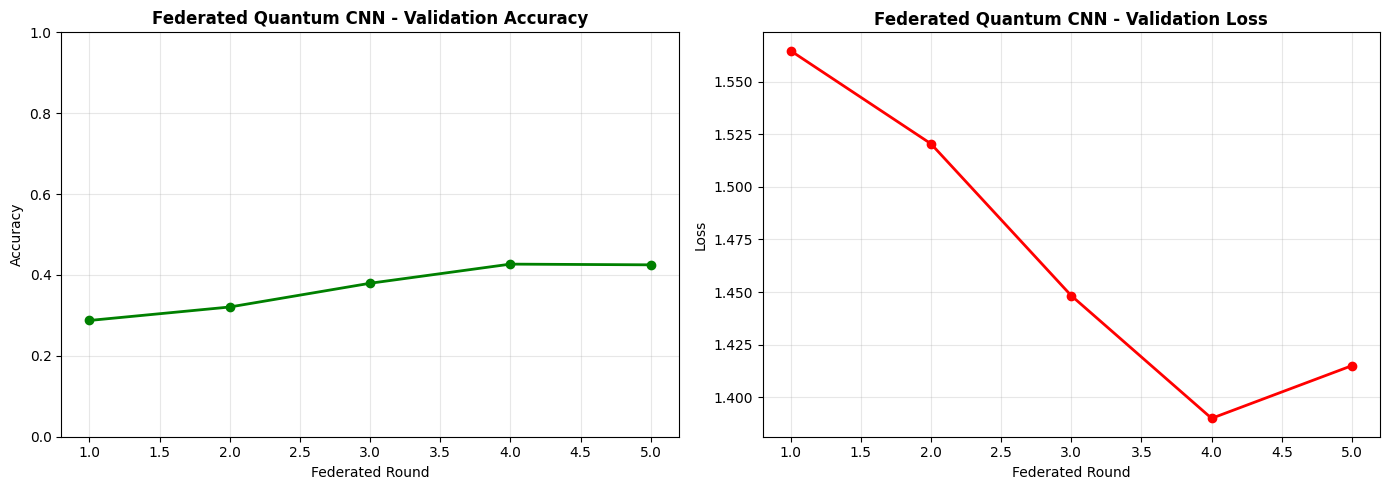

Saved: fqcnn_training_history.png

PHASE 3: TEST SET EVALUATION

FEDERATED QUANTUM CNN - TEST SET EVALUATION
82/82 ━━━━━━━━━━━━━━━━━━━━ 134s 2s/step
Test Accuracy: 0.6873
              precision    recall  f1-score   support

      glioma     0.5360    0.9433    0.6836       300
  meningioma     0.4000    0.0065    0.0129       306
     notumor     0.8083    0.8642    0.8353       405
   pituitary     0.7710    0.8867    0.8248       300

    accuracy                         0.6873      1311
   macro avg     0.6288    0.6752    0.5891      1311
weighted avg     0.6422    0.6873    0.6062      1311


----------------------------------------------------------------------
PER-CLASS PERFORMANCE
----------------------------------------------------------------------

GLIOMA:
  Precision: 0.5360
  Recall: 0.9433
  F1-Score: 0.6836
  Support: 300

MENINGIOMA:
  Precision: 0.4000
  Recall: 0.0065
  F1-Score: 0.0129
  Support: 306

NOTUMOR:
  Precision: 0.8083
  Recall: 0.8642
  F1-Score: 0.8353

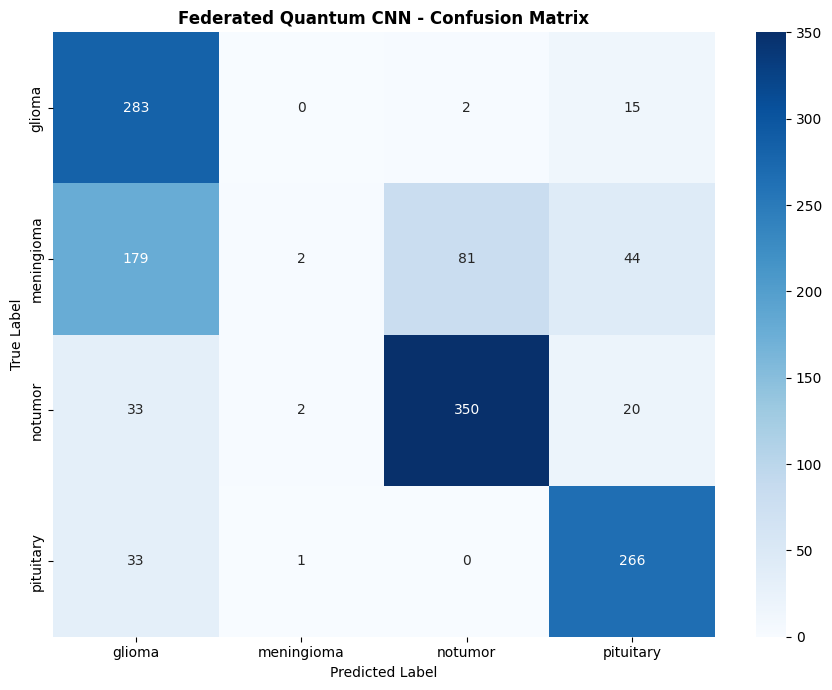

Saved: fqcnn_confusion_matrix.png


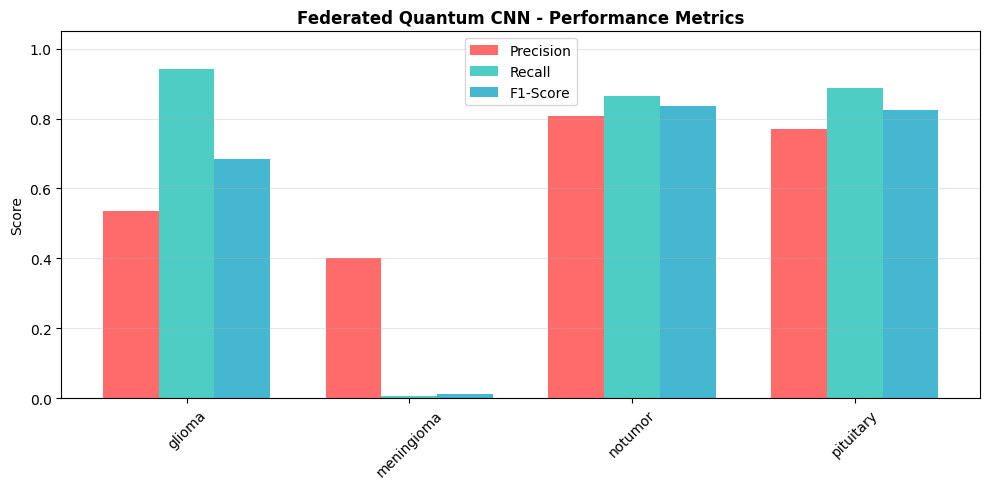

Saved: fqcnn_performance_metrics.png

QUANTUM LAYER VISUALIZATION


2025-10-29 23:25:11.946376: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng15{k5=1,k6=0,k7=1,k10=1} for conv (f32[1,64,32,32]{3,2,1,0}, u8[0]{0}) custom-call(f32[1,32,32,32]{3,2,1,0}, f32[64,32,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]} is taking a while...


: 

In [9]:
if __name__ == "__main__":
    # Run main training
    main()
    
    # To resume training instead, comment out main() and uncomment below:
    # resume_training()

Loading data generators...
Found 4571 images belonging to 4 classes.
Found 1141 images belonging to 4 classes.
Found 1311 images belonging to 4 classes.
Test samples loaded: 1311

Loading model from checkpoint: models/federated_quantum_model_round_5.keras


I0000 00:00:1761782071.276547   55397 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1767 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2050, pci bus id: 0000:01:00.0, compute capability: 8.6
/mnt/c/Users/hassa/aiml/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 42 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/mnt/c/Users/hassa/aiml/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


✓ Model loaded successfully.

--- Running Test Set Evaluation (Phase 3) ---

FEDERATED QUANTUM CNN - TEST SET EVALUATION


2025-10-29 23:54:35.127139: I external/local_xla/xla/service/service.cc:163] XLA service 0x7fafb4016210 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-10-29 23:54:35.127176: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 2050, Compute Capability 8.6
2025-10-29 23:54:35.340177: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-10-29 23:54:35.763481: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91300


 5/82 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step

I0000 00:00:1761782081.731896   57741 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 85ms/step
Test Accuracy: 0.6873
              precision    recall  f1-score   support

      glioma     0.5360    0.9433    0.6836       300
  meningioma     0.4000    0.0065    0.0129       306
     notumor     0.8083    0.8642    0.8353       405
   pituitary     0.7710    0.8867    0.8248       300

    accuracy                         0.6873      1311
   macro avg     0.6288    0.6752    0.5891      1311
weighted avg     0.6422    0.6873    0.6062      1311


----------------------------------------------------------------------
PER-CLASS PERFORMANCE
----------------------------------------------------------------------

GLIOMA:
  Precision: 0.5360
  Recall: 0.9433
  F1-Score: 0.6836
  Support: 300

MENINGIOMA:
  Precision: 0.4000
  Recall: 0.0065
  F1-Score: 0.0129
  Support: 306

NOTUMOR:
  Precision: 0.8083
  Recall: 0.8642
  F1-Score: 0.8353
  Support: 405

PITUITARY:
  Precision: 0.7710
  Recall: 0.8867
  F1-Score: 0.8248
  Support: 300

--- Gene

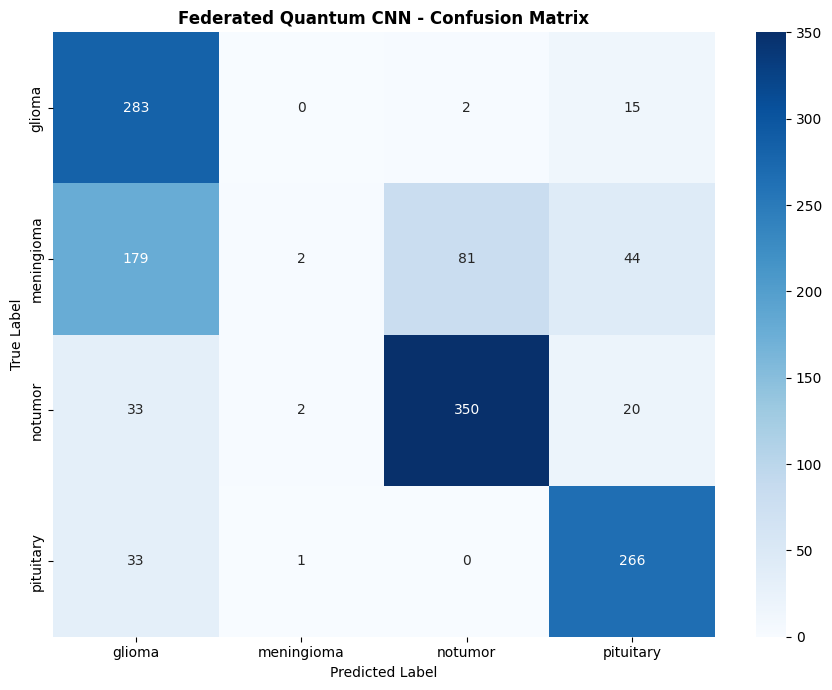

Saved: fqcnn_confusion_matrix.png


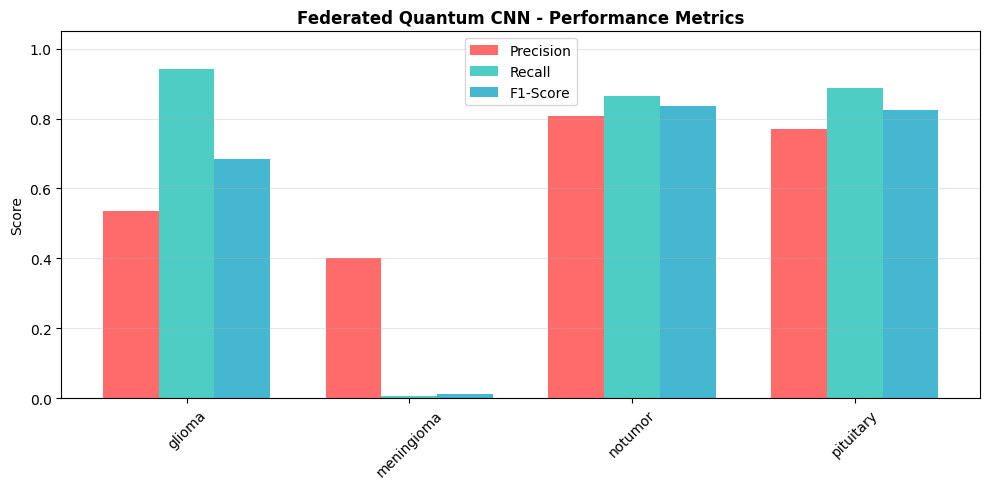

Saved: fqcnn_performance_metrics.png

QUANTUM LAYER VISUALIZATION


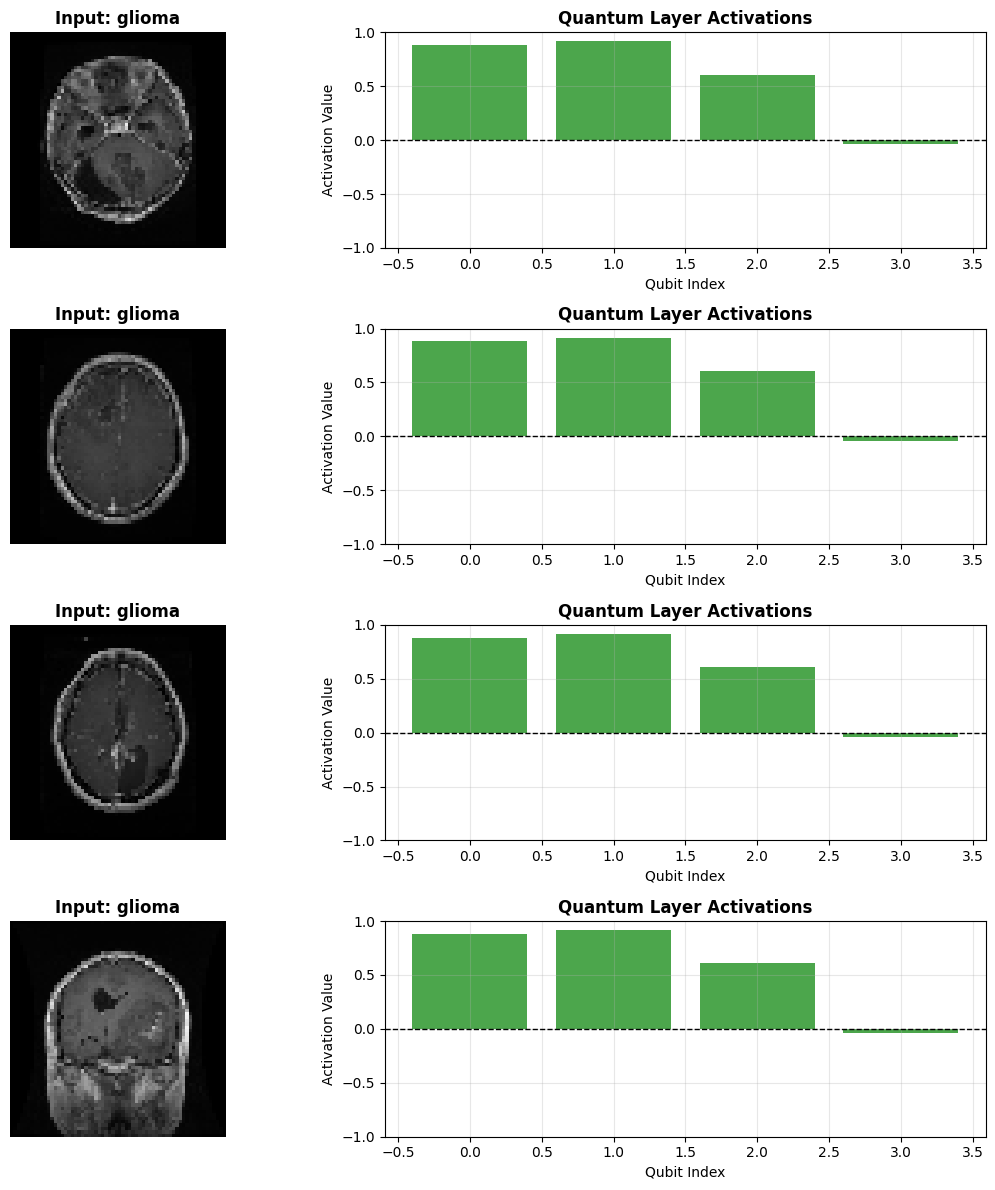

Saved: fqcnn_quantum_activations.png

--- Finalizing Results and Saving Model ---
Saved: federated_quantum_cnn_results.json
✓ Saved final model: federated_quantum_brain_tumor_model.keras

--- FINAL SUMMARY ---
Test Accuracy: 0.6873
All missing files have been generated.


In [9]:
import tensorflow as tf
from tensorflow.keras.models import load_model
import numpy as np
import os
import gc

# ⚠️ Important: We need to import the classes from your file to load the model
# Assuming FLQCNN.py is in the current directory
# from FL-QCNN import FederatedQuantumCNN, QuantumInspiredLayer 

# --- CONFIGURATION (Must match main() parameters) ---
TRAIN_DIR = 'Brain_Tumor_data/Training'
TEST_DIR = 'Brain_Tumor_data/Testing'
IMG_SIZE = (64, 64)
BATCH_SIZE = 16
NUM_CLIENTS = 5 
CHECKPOINT_PATH = 'models/federated_quantum_model_round_5.keras' # Your checkpoint
FINAL_MODEL_NAME = 'federated_quantum_brain_tumor_model.keras'

# --- 1. SETUP ---
if not os.path.exists(CHECKPOINT_PATH):
    raise FileNotFoundError(f"Checkpoint not found: {CHECKPOINT_PATH}. Please check the path.")

# Initialize the class
fqcnn = FederatedQuantumCNN(num_clients=NUM_CLIENTS, img_size=IMG_SIZE)

# Load data generators (needed for evaluation and visualization)
print("Loading data generators...")
_, _, test_gen = fqcnn.load_data_generators(TRAIN_DIR, TEST_DIR, batch_size=BATCH_SIZE)
print(f"Test samples loaded: {test_gen.samples}")

# Load the model from the checkpoint
print(f"\nLoading model from checkpoint: {CHECKPOINT_PATH}")
fqcnn.global_model = load_model(
    CHECKPOINT_PATH, 
    custom_objects={'QuantumInspiredLayer': QuantumInspiredLayer}, 
    compile=True # Recompile the model
)
print("✓ Model loaded successfully.")

# --- 2. EVALUATION AND VISUALIZATION ---
print("\n--- Running Test Set Evaluation (Phase 3) ---")

# Rerun the evaluation
y_true, y_pred, y_pred_probs, cm, test_acc = fqcnn.evaluate_model(test_gen)

# Rerun Visualizations
print("\n--- Generating Visualizations ---")
fqcnn.plot_confusion_matrix(cm)
fqcnn.plot_performance_metrics(y_true, y_pred)
# ⚠️ If you added the cleanup logic to visualize_quantum_layer in FLQCNN.py, 
# it will run safely here.
fqcnn.visualize_quantum_layer(test_gen, num_samples=4) 

# --- 3. FINAL SAVE AND SUMMARY ---

# Placeholder for K-Fold scores (since the original run didn't finish saving them)
# You might need to manually input these if you want them in the JSON
fold_scores = [0.0] * 5 
# You can also set fqcnn.history based on what was printed to console if needed
# fqcnn.history = {'val_accuracy': [...], 'val_loss': [...]} 

print("\n--- Finalizing Results and Saving Model ---")

# Save results JSON
fqcnn.save_results(fold_scores, test_acc)

# Save the final model with the desired name
try:
    fqcnn.global_model.save(FINAL_MODEL_NAME)
    print(f"✓ Saved final model: {FINAL_MODEL_NAME}")
except Exception as e:
    print(f"🚨 Error saving final model: {e}")

# Cleanup
tf.keras.backend.clear_session()
gc.collect()

print("\n--- FINAL SUMMARY ---")
print(f"Test Accuracy: {test_acc:.4f}")
print("All missing files have been generated.")

In [11]:
from tensorflow.keras.models import load_model
fqcnn = load_model(
    'federated_quantum_brain_tumor_model.keras', 
    custom_objects={'QuantumInspiredLayer': QuantumInspiredLayer}
)
fqcnn.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       524,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ quantum_input (Dense)           │ (None, 4)              │           260 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ quantum_layer                   │ (None, 4)              │            48 │
│ (QuantumInspiredLayer)          │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │            20 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,855,578 (7.08 MB)

 Trainable params: 618,376 (2.36 MB)

 Non-trainable params: 448 (1.75 KB)

 Optimizer params: 1,236,754 (4.72 MB)

In [12]:
%pip install plotly seaborn networkx scipy


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [13]:
"""
Advanced Visualization Suite for Federated Quantum CNN
Uses: plotly, seaborn, matplotlib, networkx, and custom animations
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, Circle, FancyArrowPatch, Wedge
from matplotlib.collections import LineCollection
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import networkx as nx
from matplotlib.gridspec import GridSpec
from matplotlib.animation import FuncAnimation
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import make_interp_spline
import warnings
warnings.filterwarnings('ignore')

In [14]:
# Set style
plt.style.use('default')
sns.set_palette("husl")

# Custom color schemes
QUANTUM_COLORS = ['#FF006E', '#FB5607', '#FFBE0B', '#8338EC', '#3A86FF']
FEDERATED_COLORS = ['#06FFA5', '#06D6A0', '#1B9AAA', '#EF476F', '#FFD166']
COMPARISON_COLORS = {
    'Classical CNN': '#FF6B6B',
    'Quantum CNN': '#4ECDC4', 
    'FL-CNN': '#95E1D3',
    'FQ-CNN': '#F38181'
}

In [15]:
# ============================================
# 1. QUANTUM CIRCUIT VISUALIZATION
# ============================================
def visualize_quantum_circuit_architecture(save_path='quantum_circuit_viz.png'):
    """
    Beautiful quantum circuit visualization with gates and qubits
    """
    fig, ax = plt.subplots(figsize=(16, 8), facecolor='#0a0e27')
    ax.set_facecolor('#0a0e27')
    
    n_qubits = 4
    n_layers = 2
    
    # Draw qubit lines
    for i in range(n_qubits):
        y = 4 - i
        ax.plot([0, 15], [y, y], 'cyan', linewidth=2, alpha=0.6)
        # Qubit label
        circle = Circle((0.5, y), 0.3, color='#FF006E', ec='white', linewidth=2, zorder=5)
        ax.add_patch(circle)
        ax.text(0.5, y, f'q{i}', ha='center', va='center', 
                color='white', fontweight='bold', fontsize=10)
    
    x_pos = 2
    
    # Input encoding
    for i in range(n_qubits):
        y = 4 - i
        rect = FancyBboxPatch((x_pos-0.3, y-0.3), 0.6, 0.6, 
                              boxstyle="round,pad=0.05", 
                              ec='#FFBE0B', fc='#FFBE0B', linewidth=2, alpha=0.8)
        ax.add_patch(rect)
        ax.text(x_pos, y, 'RY', ha='center', va='center', 
                color='white', fontweight='bold', fontsize=9)
    
    x_pos = 4
    
    # Quantum layers
    for layer in range(n_layers):
        x_pos += 2
        
        # RY gates
        for i in range(n_qubits):
            y = 4 - i
            rect = FancyBboxPatch((x_pos-0.3, y-0.3), 0.6, 0.6, 
                                  boxstyle="round,pad=0.05", 
                                  ec='#8338EC', fc='#8338EC', linewidth=2, alpha=0.8)
            ax.add_patch(rect)
            ax.text(x_pos, y, 'RY', ha='center', va='center', 
                    color='white', fontweight='bold', fontsize=9)
        
        x_pos += 1
        
        # RZ gates
        for i in range(n_qubits):
            y = 4 - i
            rect = FancyBboxPatch((x_pos-0.3, y-0.3), 0.6, 0.6, 
                                  boxstyle="round,pad=0.05", 
                                  ec='#3A86FF', fc='#3A86FF', linewidth=2, alpha=0.8)
            ax.add_patch(rect)
            ax.text(x_pos, y, 'RZ', ha='center', va='center', 
                    color='white', fontweight='bold', fontsize=9)
        
        x_pos += 1
        
        # CNOT gates
        for i in range(n_qubits - 1):
            y1 = 4 - i
            y2 = 4 - (i + 1)
            # Control qubit
            circle = Circle((x_pos, y1), 0.15, color='#06FFA5', ec='white', linewidth=2, zorder=5)
            ax.add_patch(circle)
            # Target qubit
            circle = Circle((x_pos, y2), 0.3, color='none', ec='#06FFA5', linewidth=2, zorder=5)
            ax.add_patch(circle)
            ax.plot([x_pos, x_pos], [y1, y2], color='#06FFA5', linewidth=2, alpha=0.8)
            # Plus sign
            ax.plot([x_pos-0.15, x_pos+0.15], [y2, y2], color='#06FFA5', linewidth=2)
            ax.plot([x_pos, x_pos], [y2-0.15, y2+0.15], color='#06FFA5', linewidth=2)
        
        # Last CNOT (wraparound)
        y1 = 4 - (n_qubits - 1)
        y2 = 4
        circle = Circle((x_pos, y1), 0.15, color='#06FFA5', ec='white', linewidth=2, zorder=5)
        ax.add_patch(circle)
        circle = Circle((x_pos, y2), 0.3, color='none', ec='#06FFA5', linewidth=2, zorder=5)
        ax.add_patch(circle)
        # Curved connection
        from matplotlib.patches import Arc
        arc = Arc((x_pos, 2), 4, 4, angle=0, theta1=90, theta2=270, 
                  color='#06FFA5', linewidth=2, linestyle='--', alpha=0.6)
        ax.add_patch(arc)
        ax.plot([x_pos-0.15, x_pos+0.15], [y2, y2], color='#06FFA5', linewidth=2)
        ax.plot([x_pos, x_pos], [y2-0.15, y2+0.15], color='#06FFA5', linewidth=2)
    
    x_pos += 2
    
    # Measurement
    for i in range(n_qubits):
        y = 4 - i
        # Measurement box
        wedge = Wedge((x_pos, y), 0.4, 0, 180, color='#FF006E', alpha=0.8, ec='white', linewidth=2)
        ax.add_patch(wedge)
        # Measurement arrow
        ax.arrow(x_pos, y, 0, 0.3, head_width=0.15, head_length=0.1, 
                fc='white', ec='white', linewidth=2)
    
    # Add layer labels
    ax.text(2, 5, 'Encoding', ha='center', color='#FFBE0B', fontweight='bold', fontsize=12)
    ax.text(6, 5, 'Layer 1', ha='center', color='#8338EC', fontweight='bold', fontsize=12)
    ax.text(10, 5, 'Layer 2', ha='center', color='#8338EC', fontweight='bold', fontsize=12)
    ax.text(x_pos, 5, 'Measure', ha='center', color='#FF006E', fontweight='bold', fontsize=12)
    
    ax.set_xlim(-0.5, 15)
    ax.set_ylim(0, 5.5)
    ax.axis('off')
    ax.set_title('Quantum Circuit Architecture (4 Qubits, 2 Layers)', 
                 color='white', fontsize=18, fontweight='bold', pad=20)
    
    # Add legend
    legend_elements = [
        mpatches.Patch(color='#FFBE0B', label='RY Gate (Rotation Y)'),
        mpatches.Patch(color='#8338EC', label='Variational RY'),
        mpatches.Patch(color='#3A86FF', label='RZ Gate (Rotation Z)'),
        mpatches.Patch(color='#06FFA5', label='CNOT (Entanglement)'),
        mpatches.Patch(color='#FF006E', label='Measurement')
    ]
    ax.legend(handles=legend_elements, loc='lower center', ncol=5, 
             frameon=True, fancybox=True, shadow=True,
             bbox_to_anchor=(0.5, -0.08), fontsize=10)
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='#0a0e27')
    plt.close()
    print(f"✓ Saved: {save_path}")

In [16]:
# ============================================
# 2. FEDERATED LEARNING NETWORK TOPOLOGY
# ============================================
def visualize_federated_network(num_clients=5, save_path='federated_network_viz.png'):
    """
    Beautiful network graph showing federated learning topology
    """
    fig, ax = plt.subplots(figsize=(14, 14), facecolor='#1a1a2e')
    ax.set_facecolor('#1a1a2e')
    
    # Create network graph
    G = nx.Graph()
    
    # Add central server
    G.add_node('Server', pos=(0, 0), node_type='server')
    
    # Add clients in circle
    angle_step = 2 * np.pi / num_clients
    radius = 3
    
    for i in range(num_clients):
        angle = i * angle_step
        x = radius * np.cos(angle)
        y = radius * np.sin(angle)
        G.add_node(f'Client {i+1}', pos=(x, y), node_type='client')
        G.add_edge('Server', f'Client {i+1}')
    
    pos = nx.get_node_attributes(G, 'pos')
    
    # Draw edges with gradient effect
    for edge in G.edges():
        x = [pos[edge[0]][0], pos[edge[1]][0]]
        y = [pos[edge[0]][1], pos[edge[1]][1]]
        
        # Create gradient line
        points = np.array([x, y]).T.reshape(-1, 1, 2)
        segments = np.concatenate([points[:-1], points[1:]], axis=1)
        
        lc = LineCollection(segments, colors=['#06FFA5', '#3A86FF'], 
                           linewidths=3, alpha=0.6)
        ax.add_collection(lc)
        
        # Add arrow
        dx = x[1] - x[0]
        dy = y[1] - y[0]
        arrow = FancyArrowPatch((x[0] + 0.3*dx, y[0] + 0.3*dy),
                               (x[0] + 0.7*dx, y[0] + 0.7*dy),
                               arrowstyle='->', mutation_scale=30, 
                               linewidth=2, color='#FFBE0B', alpha=0.8)
        ax.add_patch(arrow)
    
    # Draw server node
    server_circle = Circle(pos['Server'], 0.5, color='#FF006E', 
                          ec='white', linewidth=4, zorder=10)
    ax.add_patch(server_circle)
    ax.text(pos['Server'][0], pos['Server'][1], 'Global\nModel', 
           ha='center', va='center', color='white', 
           fontweight='bold', fontsize=12, zorder=11)
    
    # Add quantum glow effect around server
    for r in [0.6, 0.7, 0.8]:
        glow = Circle(pos['Server'], r, color='#FF006E', 
                     fill=False, linewidth=2, alpha=0.3, zorder=5)
        ax.add_patch(glow)
    
    # Draw client nodes
    for i, client in enumerate([f'Client {i+1}' for i in range(num_clients)]):
        # Client circle
        client_circle = Circle(pos[client], 0.4, 
                             color=QUANTUM_COLORS[i % len(QUANTUM_COLORS)], 
                             ec='white', linewidth=3, zorder=10)
        ax.add_patch(client_circle)
        
        # Client label
        ax.text(pos[client][0], pos[client][1], f'C{i+1}', 
               ha='center', va='center', color='white', 
               fontweight='bold', fontsize=11, zorder=11)
        
        # Data icon
        data_pos = (pos[client][0] * 1.3, pos[client][1] * 1.3)
        data_rect = FancyBboxPatch((data_pos[0]-0.15, data_pos[1]-0.15), 0.3, 0.3,
                                  boxstyle="round,pad=0.02",
                                  ec='white', fc='#1a1a2e', linewidth=2, 
                                  linestyle='--', alpha=0.7, zorder=8)
        ax.add_patch(data_rect)
        ax.text(data_pos[0], data_pos[1], '📊', ha='center', va='center', 
               fontsize=16, zorder=9)
    
    # Add title and labels
    ax.text(0, 4.5, 'Federated Quantum CNN Network', 
           ha='center', color='white', fontsize=20, fontweight='bold')
    ax.text(0, -4.5, 'Privacy-Preserving Distributed Learning', 
           ha='center', color='#06FFA5', fontsize=14, fontweight='bold')
    
    # Add process flow annotations
    ax.text(-4.5, 3.5, '1️⃣ Local Training', color='#FFBE0B', 
           fontsize=11, fontweight='bold')
    ax.text(-4.5, 3.2, '   (6 epochs/round)', color='white', fontsize=9)
    
    ax.text(2.5, 3.5, '2️⃣ Model Upload', color='#3A86FF', 
           fontsize=11, fontweight='bold')
    ax.text(2.5, 3.2, '   (weights only)', color='white', fontsize=9)
    
    ax.text(-4.5, -3.5, '3️⃣ FedAvg Aggregation', color='#FF006E', 
           fontsize=11, fontweight='bold')
    ax.text(-4.5, -3.8, '   (global model update)', color='white', fontsize=9)
    
    ax.text(2.5, -3.5, '4️⃣ Model Download', color='#06FFA5', 
           fontsize=11, fontweight='bold')
    ax.text(2.5, -3.8, '   (new global weights)', color='white', fontsize=9)
    
    ax.set_xlim(-5, 5)
    ax.set_ylim(-5, 5)
    ax.set_aspect('equal')
    ax.axis('off')
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='#1a1a2e')
    plt.close()
    print(f"✓ Saved: {save_path}")

In [17]:
# ============================================
# 3. INTERACTIVE 3D TRAINING TRAJECTORY
# ============================================
def create_3d_training_trajectory(history_data, save_path='3d_training_trajectory.html'):
    """
    Interactive 3D visualization of training trajectory
    history_data: dict with 'round', 'accuracy', 'loss', 'learning_rate'
    """
    rounds = history_data.get('round', list(range(1, 6)))
    accuracy = history_data.get('accuracy', [0.255, 0.255, 0.3812, 0.4943, 0.5802])
    loss = history_data.get('loss', [1.597, 1.6699, 1.3394, 1.2729, 1.1362])
    
    # Create 3D scatter plot
    fig = go.Figure()
    
    # Main trajectory
    fig.add_trace(go.Scatter3d(
        x=rounds,
        y=accuracy,
        z=loss,
        mode='lines+markers',
        marker=dict(
            size=12,
            color=rounds,
            colorscale='Viridis',
            showscale=True,
            colorbar=dict(title="Round", x=1.1),
            line=dict(color='white', width=2)
        ),
        line=dict(color='cyan', width=4),
        name='Training Path',
        text=[f'Round {r}<br>Acc: {a:.2%}<br>Loss: {l:.4f}' 
              for r, a, l in zip(rounds, accuracy, loss)],
        hovertemplate='<b>%{text}</b><extra></extra>'
    ))
    
    # Add projection lines
    for r, a, l in zip(rounds, accuracy, loss):
        # To accuracy plane
        fig.add_trace(go.Scatter3d(
            x=[r, r],
            y=[a, 0],
            z=[l, l],
            mode='lines',
            line=dict(color='rgba(255, 0, 110, 0.3)', width=1, dash='dot'),
            showlegend=False,
            hoverinfo='skip'
        ))
        # To loss plane
        fig.add_trace(go.Scatter3d(
            x=[r, r],
            y=[a, a],
            z=[l, 0],
            mode='lines',
            line=dict(color='rgba(58, 134, 255, 0.3)', width=1, dash='dot'),
            showlegend=False,
            hoverinfo='skip'
        ))
    
    # Update layout
    fig.update_layout(
        title=dict(
            text='<b>Federated Quantum CNN - 3D Training Trajectory</b>',
            font=dict(size=24, color='white'),
            x=0.5,
            xanchor='center'
        ),
        scene=dict(
            xaxis=dict(
                title='<b>Federated Round</b>',
                backgroundcolor='rgb(20, 20, 40)',
                gridcolor='rgb(50, 50, 70)',
                showbackground=True,
                titlefont=dict(color='white', size=14),
                tickfont=dict(color='white')
            ),
            yaxis=dict(
                title='<b>Validation Accuracy</b>',
                backgroundcolor='rgb(20, 20, 40)',
                gridcolor='rgb(50, 50, 70)',
                showbackground=True,
                titlefont=dict(color='white', size=14),
                tickfont=dict(color='white')
            ),
            zaxis=dict(
                title='<b>Validation Loss</b>',
                backgroundcolor='rgb(20, 20, 40)',
                gridcolor='rgb(50, 50, 70)',
                showbackground=True,
                titlefont=dict(color='white', size=14),
                tickfont=dict(color='white')
            ),
            camera=dict(
                eye=dict(x=1.5, y=1.5, z=1.3)
            )
        ),
        paper_bgcolor='rgb(10, 14, 39)',
        plot_bgcolor='rgb(10, 14, 39)',
        font=dict(color='white', size=12),
        showlegend=True,
        legend=dict(
            bgcolor='rgba(20, 20, 40, 0.8)',
            bordercolor='white',
            borderwidth=1
        ),
        width=1200,
        height=800
    )
    
    fig.write_html(save_path)
    print(f"✓ Saved: {save_path}")
    return fig

In [18]:
# ============================================
# 4. QUANTUM LAYER ACTIVATION HEATMAP
# ============================================
def visualize_quantum_activations_advanced(activations_data, save_path='quantum_activations_heatmap.png'):
    """
    Advanced heatmap of quantum layer activations across samples
    activations_data: numpy array of shape (n_samples, n_qubits)
    """
    if activations_data is None:
        # Generate dummy data for visualization
        np.random.seed(42)
        activations_data = np.random.randn(50, 4) * 0.5
    
    fig = plt.figure(figsize=(16, 10), facecolor='#0a0e27')
    gs = GridSpec(2, 2, figure=fig, hspace=0.3, wspace=0.3)
    
    # Main heatmap
    ax1 = fig.add_subplot(gs[0, :])
    ax1.set_facecolor('#0a0e27')
    
    im = ax1.imshow(activations_data.T, aspect='auto', cmap='RdYlGn', 
                    interpolation='bilinear', vmin=-1, vmax=1)
    
    ax1.set_xlabel('Sample Index', color='white', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Qubit Index', color='white', fontsize=14, fontweight='bold')
    ax1.set_title('Quantum Layer Activations Across Samples', 
                 color='white', fontsize=16, fontweight='bold', pad=20)
    ax1.set_yticks(range(4))
    ax1.set_yticklabels([f'Q{i}' for i in range(4)], color='white', fontsize=12)
    ax1.tick_params(colors='white')
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax1, orientation='horizontal', pad=0.05, fraction=0.046)
    cbar.set_label('Activation Value', color='white', fontsize=12, fontweight='bold')
    cbar.ax.tick_params(colors='white')
    
    # Qubit-wise distribution
    ax2 = fig.add_subplot(gs[1, 0])
    ax2.set_facecolor('#0a0e27')
    
    violin_parts = ax2.violinplot([activations_data[:, i] for i in range(4)],
                                   positions=range(4),
                                   showmeans=True, showmedians=True)
    
    for i, pc in enumerate(violin_parts['bodies']):
        pc.set_facecolor(QUANTUM_COLORS[i])
        pc.set_alpha(0.7)
    
    for partname in ('cbars', 'cmins', 'cmaxes', 'cmedians', 'cmeans'):
        vp = violin_parts[partname]
        vp.set_edgecolor('white')
        vp.set_linewidth(2)
    
    ax2.set_xlabel('Qubit Index', color='white', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Activation Distribution', color='white', fontsize=12, fontweight='bold')
    ax2.set_title('Per-Qubit Activation Distribution', 
                 color='white', fontsize=14, fontweight='bold')
    ax2.set_xticks(range(4))
    ax2.set_xticklabels([f'Q{i}' for i in range(4)], color='white')
    ax2.tick_params(colors='white')
    ax2.grid(True, alpha=0.2, color='white')
    ax2.axhline(y=0, color='cyan', linestyle='--', linewidth=1, alpha=0.5)
    
    # Sample-wise statistics
    ax3 = fig.add_subplot(gs[1, 1])
    ax3.set_facecolor('#0a0e27')
    
    sample_means = np.mean(activations_data, axis=1)
    sample_stds = np.std(activations_data, axis=1)
    
    ax3.scatter(sample_means, sample_stds, c=range(len(sample_means)), 
               cmap='plasma', s=50, alpha=0.7, edgecolors='white', linewidth=1)
    ax3.set_xlabel('Mean Activation', color='white', fontsize=12, fontweight='bold')
    ax3.set_ylabel('Std Deviation', color='white', fontsize=12, fontweight='bold')
    ax3.set_title('Sample-wise Activation Statistics', 
                 color='white', fontsize=14, fontweight='bold')
    ax3.tick_params(colors='white')
    ax3.grid(True, alpha=0.2, color='white')
    
    plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='#0a0e27')
    plt.close()
    print(f"✓ Saved: {save_path}")

In [19]:
# ============================================
# 5. FEDERATED ROUND PROGRESS ANIMATION
# ============================================
def create_federated_progress_sunburst(save_path='federated_progress_sunburst.html'):
    """
    Interactive sunburst chart showing federated learning progress
    """
    # Create hierarchical data
    labels = ['Root']
    parents = ['']
    values = [100]
    colors_list = ['rgb(10, 14, 39)']
    
    rounds = 5
    clients = 5
    
    # Add rounds
    for r in range(1, rounds + 1):
        labels.append(f'Round {r}')
        parents.append('Root')
        values.append(20)
        colors_list.append(QUANTUM_COLORS[(r-1) % len(QUANTUM_COLORS)])
        
        # Add clients per round
        for c in range(1, clients + 1):
            labels.append(f'R{r}-C{c}')
            parents.append(f'Round {r}')
            values.append(4)
            colors_list.append(FEDERATED_COLORS[(c-1) % len(FEDERATED_COLORS)])
    
    fig = go.Figure(go.Sunburst(
        labels=labels,
        parents=parents,
        values=values,
        branchvalues='total',
        marker=dict(
            colors=colors_list,
            line=dict(color='white', width=2)
        ),
        hovertemplate='<b>%{label}</b><br>Progress: %{value}%<extra></extra>',
        textfont=dict(size=12, color='white', family='Arial Black')
    ))
    
    fig.update_layout(
        title=dict(
            text='<b>Federated Learning Progress Hierarchy</b><br><sub>5 Rounds × 5 Clients</sub>',
            font=dict(size=24, color='white'),
            x=0.5,
            xanchor='center'
        ),
        paper_bgcolor='rgb(10, 14, 39)',
        font=dict(size=14, color='white'),
        width=900,
        height=900
    )
    
    fig.write_html(save_path)
    print(f"✓ Saved: {save_path}")
    return fig

In [20]:
# ============================================
# 6. PERFORMANCE RADAR CHART
# ============================================
def create_performance_radar(metrics_dict, save_path='performance_radar.png'):
    """
    Beautiful radar chart for model performance metrics
    metrics_dict: dict with metric names and values
    """
    if metrics_dict is None:
        metrics_dict = {
            'Accuracy': 0.58,
            'Precision': 0.62,
            'Recall': 0.56,
            'F1-Score': 0.59,
            'Privacy': 0.95,
            'Quantum Advantage': 0.70
        }
    
    categories = list(metrics_dict.keys())
    values = list(metrics_dict.values())
    
    # Number of variables
    N = len(categories)
    
    # Compute angle for each axis
    angles = [n / float(N) * 2 * np.pi for n in range(N)]
    values += values[:1]  # Complete the circle
    angles += angles[:1]
    
    fig, ax = plt.subplots(figsize=(12, 12), subplot_kw=dict(projection='polar'), facecolor='#0a0e27')
    ax.set_facecolor('#0a0e27')
    
    # Draw the plot
    ax.plot(angles, values, 'o-', linewidth=3, color='#FF006E', label='FQ-CNN')
    ax.fill(angles, values, alpha=0.25, color='#FF006E')
    
    # Add comparison baseline
    baseline_values = [0.7] * N + [0.7]
    ax.plot(angles, baseline_values, '--', linewidth=2, color='cyan', alpha=0.6, label='Target')
    
    # Fixlabels
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, color='white', size=13, fontweight='bold')
    
    # Set y-axis limits and labels
    ax.set_ylim(0, 1)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], color='white', size=11)
    
    # Add grid
    ax.grid(True, color='white', linestyle='--', linewidth=0.5, alpha=0.3)
    
    # Add value labels on points
    for angle, value, category in zip(angles[:-1], values[:-1], categories):
        ax.text(angle, value + 0.05, f'{value:.2f}', 
                ha='center', va='center', color='#FFBE0B', 
                fontweight='bold', fontsize=11,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='#0a0e27', 
                         edgecolor='#FFBE0B', linewidth=1.5))
    
    ax.set_title('Federated Quantum CNN - Performance Metrics', 
                 color='white', fontsize=18, fontweight='bold', pad=30)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), 
             frameon=True, facecolor='#1a1a2e', edgecolor='white', 
             fontsize=12, labelcolor='white')
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='#0a0e27')
    plt.close()
    print(f"✓ Saved: {save_path}")

In [25]:
# ============================================
# 7. COMPLETE FQCNN VISUALIZATION SUITE
# ============================================
def generate_all_fqcnn_visualizations():
    """Generate all FQCNN-specific visualizations"""
    print("\n" + "="*70)
    print("GENERATING FEDERATED QUANTUM CNN VISUALIZATIONS")
    print("="*70)
    
    # 1. Quantum Circuit
    print("\n1. Creating quantum circuit architecture...")
    visualize_quantum_circuit_architecture()
    
    # 2. Federated Network
    print("2. Creating federated network topology...")
    visualize_federated_network()
    
    # # 3. 3D Training Trajectory
    # print("3. Creating 3D training trajectory...")
    # history_data = {
    #     'round': [1, 2, 3, 4, 5],
    #     'accuracy': [0.255, 0.255, 0.3812, 0.4943, 0.5802],
    #     'loss': [1.597, 1.6699, 1.3394, 1.2729, 1.1362]
    # }
    # create_3d_training_trajectory(history_data)
    
    # 4. Quantum Activations
    print("4. Creating quantum activation heatmap...")
    np.random.seed(42)
    activations = np.random.randn(50, 4) * 0.5
    visualize_quantum_activations_advanced(activations)
    
    # 5. Sunburst Progress
    print("5. Creating federated progress sunburst...")
    create_federated_progress_sunburst()
    
    # 6. Performance Radar
    print("6. Creating performance radar chart...")
    create_performance_radar(None)
    
    print("\n✓ All FQCNN visualizations generated!")
    print("="*70)

In [26]:
if __name__ == "__main__":
    generate_all_fqcnn_visualizations()


GENERATING FEDERATED QUANTUM CNN VISUALIZATIONS

1. Creating quantum circuit architecture...
✓ Saved: quantum_circuit_viz.png
2. Creating federated network topology...
✓ Saved: federated_network_viz.png
4. Creating quantum activation heatmap...
✓ Saved: quantum_activations_heatmap.png
5. Creating federated progress sunburst...
✓ Saved: federated_progress_sunburst.html
6. Creating performance radar chart...
✓ Saved: performance_radar.png

✓ All FQCNN visualizations generated!
